# NullVector + LangGraph: End-to-End Document QA Cookbook

This notebook walks through a complete, in-memory document question-answering pipeline that combines:

- **NullVector** — deterministic PDF acquisition, hierarchy building, and typed retrieval
- **LangGraph** — stateful agent orchestration with `MemorySaver` (in-memory checkpointing)
- **OpenRouter** — LLM backbone (gemini-3.1-flash-lite-preview)

## What you will build

```
PDF file
  └─► NullVector Acquisition  ──► CanonicalDocumentLedger
        └─► (optional) Tree Build  ──► HierarchyNodes
              └─► RetrievalCorpus  ──► InMemoryRetrievalIndex
                    └─► LangGraph ReAct Agent  ──► MemorySaver
                          ├─ search_document (NullVector retrieval tool)
                          └─ get_page_text    (NullVector page tool)
```

## Prerequisites

- Python 3.11+
- **PyMuPDF exactly 1.27.2** and **pypdf exactly 6.8.0** (NullVector version-locks these)
- The `nullvector` package installed from your project root


In [1]:
# ── 1. INSTALLATION ─────────────────────────────────────────────────────────
# NullVector version-locks PyMuPDF and pypdf. Install those first.
# If you already have nullvector installed from your project root,
# skip the last line.

!uv pip install -q \
    "pymupdf==1.27.2" \
    "pypdf==6.8.0" \
    "langgraph>=0.2" \
    "langchain-openai>=0.1" \
    "langchain-core>=0.2" \
    "fpdf2>=2.7" \
    "litellm>=1.40" \
    "pydantic>=2.5"

# Install nullvector from the project root (edit path as needed):
# %pip install -q -e /home/pruthvi/projects/NullVector

In [2]:
# ── 2. CONFIGURATION ────────────────────────────────────────────────────────
import os
import tempfile
from pathlib import Path

# OpenRouter credentials
OPENROUTER_API_KEY = "REDACTED_OPENROUTER_KEY"
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"

# Text model (tool-calling, ReAct agent)
LANGCHAIN_MODEL = "google/gemini-3.1-flash-lite-preview"

# Vision model — must support image_url inputs on OpenRouter
# gemini-2.0-flash supports vision and is available on OpenRouter.
VISION_LANGCHAIN_MODEL = "google/gemini-3.1-flash-lite-preview"
VISION_LITELLM_MODEL = "openrouter/google/gemini-3.1-flash-lite-preview"

# NullVector LiteLLM model (used in bonus gateway section)
LITELLM_MODEL = "openrouter/google/gemini-3.1-flash-lite-preview"

# ── PDF path — point at YOUR document ───────────────────────────────────────
PDF_PATH = "/home/pruthvi/projects/NullVector/cookbook/903000608.pdf"
assert Path(PDF_PATH).exists(), f"PDF not found: {PDF_PATH}"
print(f"Using PDF: {PDF_PATH}  ({Path(PDF_PATH).stat().st_size:,} bytes)")

# Set env vars so LangChain OpenAI client picks them up
os.environ["OPENAI_API_KEY"] = OPENROUTER_API_KEY
os.environ["OPENAI_API_BASE"] = OPENROUTER_BASE_URL
# Also set for LiteLLM's OpenRouter provider
os.environ["OPENROUTER_API_KEY"] = OPENROUTER_API_KEY

# Artifact storage
ARTIFACT_DIR = tempfile.mkdtemp(prefix="nullvector_cookbook_")
print(f"Artifact directory: {ARTIFACT_DIR}")

Using PDF: /home/pruthvi/projects/NullVector/cookbook/903000608.pdf  (6,254,823 bytes)
Artifact directory: /tmp/nullvector_cookbook_8fjwbr4g


In [3]:
# ── 3. INSPECT THE PDF ──────────────────────────────────────────────────────
# Quick look at page count and image density before we run acquisition.
# NullVector will turn every embedded image into a VisualArtifact block and
# any image-only or dense-vector page into an UnresolvedRegion block.

import fitz  # PyMuPDF

with fitz.open(PDF_PATH) as _doc:
    _page_count = _doc.page_count
    _image_pages = []
    for _i in range(_page_count):
        _p = _doc[_i]
        _imgs = _p.get_image_info()
        if _imgs:
            _image_pages.append((_i, len(_imgs)))

print(f"Pages              : {_page_count}")
print(f"Pages with images  : {len(_image_pages)}")
if _image_pages:
    print("First image-bearing pages:")
    for _pg, _n in _image_pages[:6]:
        print(f"  page {_pg + 1}: {_n} image(s)")
else:
    print(
        "No embedded images found via get_image_info() — may still have vector/unresolved regions."
    )

Pages              : 148
Pages with images  : 81
First image-bearing pages:
  page 1: 4 image(s)
  page 3: 2 image(s)
  page 5: 1 image(s)
  page 7: 1 image(s)
  page 11: 8 image(s)
  page 12: 1 image(s)


In [4]:
# ── 4. NULLVECTOR ACQUISITION ────────────────────────────────────────────────
# AcquisitionService reads the PDF with native PyMuPDF, extracts text blocks,
# line blocks, table artefacts, outlines, and writes a canonical ledger to disk.
# It also builds the canonical text substrate and projection view in one pass.

from nullvector.domain import AcquisitionRequest
from nullvector.ingest import acquire_document

ACQUISITION_RUN_ID = "cookbook-acq-001"

acquisition_request = AcquisitionRequest(
    source_path=PDF_PATH,
    acquisition_run_id=ACQUISITION_RUN_ID,
    artifact_root=ARTIFACT_DIR,
)

acq_manifest = acquire_document(acquisition_request)

print("=" * 60)
print("ACQUISITION COMPLETE")
print("=" * 60)
print(f"Document ID   : {acq_manifest.document_id}")
print(f"Page count    : {acq_manifest.page_count}")
print(f"Artifact root : {acq_manifest.artifact_root}")
print(f"Outline source: {acq_manifest.selected_outline_source}")

# The canonical text substrate path is needed for downstream steps
ACQ_MANIFEST_PATH = str(Path(acq_manifest.artifact_root) / "manifest.json")

'utf-16-be' codec can't decode byte 0x31 in position 16: truncated data
initial string:b'\xfe\xff\x00_\x00P\x00A\x00G\x00E\x001.41'
'utf-16-be' codec can't decode byte 0x44 in position 16: truncated data
initial string:b'\xfe\xff\x00_\x00P\x00A\x00G\x00E\x001.cD'
Removed unexpected destination b'\xfe\xff\x00_\x00P\x00A\x00G\x00E\x001.cD' from destination
Removed unexpected destination b'\xfe\xff\x00_\x00P\x00A\x00G\x00E\x001.41' from destination
'utf-16-be' codec can't decode byte 0x31 in position 16: truncated data
initial string:b'\xfe\xff\x00_\x00P\x00A\x00G\x00E\x001.41'
'utf-16-be' codec can't decode byte 0x44 in position 16: truncated data
initial string:b'\xfe\xff\x00_\x00P\x00A\x00G\x00E\x001.cD'
Removed unexpected destination b'\xfe\xff\x00_\x00P\x00A\x00G\x00E\x001.cD' from destination
Removed unexpected destination b'\xfe\xff\x00_\x00P\x00A\x00G\x00E\x001.41' from destination


ACQUISITION COMPLETE
Document ID   : 798d2f27d45d2ccda3694005c2ed60bc0b413b8b299f3a5d4ade7c5867094896
Page count    : 148
Artifact root : /tmp/nullvector_cookbook_8fjwbr4g/cookbook-acq-001/798d2f27d45d2ccda3694005c2ed60bc0b413b8b299f3a5d4ade7c5867094896
Outline source: pymupdf


In [5]:
# ── 5. (OPTIONAL) NULLVECTOR TREE BUILD ────────────────────────────────────
RUN_TREE_BUILD = True
TREE_MANIFEST_PATH = None

if RUN_TREE_BUILD:
    from nullvector.domain import TreeBuildRequest  # domain contract
    from nullvector.tree import build_tree  # service layer

    tree_request = TreeBuildRequest(
        acquisition_manifest_path=ACQ_MANIFEST_PATH,
        tree_run_id="cookbook-tree-001",
        summarize=False,
    )
    tree_manifest = build_tree(tree_request)
    TREE_MANIFEST_PATH = str(Path(tree_manifest.artifact_root) / "manifest.json")

    print("=" * 60)
    print("TREE BUILD COMPLETE")
    print("=" * 60)
    print(f"Committed nodes    : {tree_manifest.committed_node_count}")
    print(f"Unassigned spans   : {tree_manifest.unassigned_span_count}")
    print(f"Artifact root      : {tree_manifest.artifact_root}")
else:
    print("Tree build skipped — corpus will contain page-level units only.")

TREE BUILD COMPLETE
Committed nodes    : 3000
Unassigned spans   : 1
Artifact root      : /tmp/nullvector_cookbook_8fjwbr4g/cookbook-acq-001/798d2f27d45d2ccda3694005c2ed60bc0b413b8b299f3a5d4ade7c5867094896/tree/cookbook-tree-001


In [6]:
# ── 6. BUILD RETRIEVAL CORPUS AND IN-MEMORY INDEX ───────────────────────────
# RetrievalCorpusBuilder assembles all evidence units:
#   • PAGE_TEXT       — full page text (always present)
#   • TABLE           — detected tabular regions
#   • VISUAL          — embedded images
#   • NODE_TEXT       — per-node owned text (if tree was built)
#   • NODE_SUMMARY    — LLM-generated summaries (if summarize=True was used)
#   • UNASSIGNED_SPAN — pages not owned by any verified node
#
# InMemoryRetrievalIndex builds posting lists in RAM for instant BM25-like
# scoring — no vector store, no embeddings required.

from nullvector.retrieval import (
    InMemoryRetrievalIndex,
    QueryPlanner,
    RetrievalCorpusBuilder,
    RetrievalRanker,
    RetrievalService,
    load_retrieval_corpus,
)

builder = RetrievalCorpusBuilder()
retrieval_manifest = builder.build(
    acquisition_manifest_path=ACQ_MANIFEST_PATH,
    tree_manifest_path=TREE_MANIFEST_PATH,  # None → page-only corpus
)

# Load corpus from the written JSON artefact
corpus = load_retrieval_corpus(retrieval_manifest.corpus_path)

# Build the in-memory index — this is cheap and fast
index = InMemoryRetrievalIndex(corpus)

print("=" * 60)
print("RETRIEVAL CORPUS READY")
print("=" * 60)
print(f"Total units  : {retrieval_manifest.unit_count}")
print(f"Document ID  : {corpus.document_id}")
from collections import Counter

counts = Counter(u.unit_type.value for u in corpus.units)
for unit_type, n in sorted(counts.items()):
    print(f"  {unit_type:<22}: {n}")

# Set up the retrieval service (planner + ranker + index wrapper)
planner = QueryPlanner()
ranker = RetrievalRanker()
service = RetrievalService(planner, ranker)

# Quick sanity check
hits = service.search(corpus=corpus, query="neural network activation functions", limit=3)
print("\nTop-3 hits for sanity-check query:")
for h in hits:
    snippet = (h.unit.text or "")[:120].replace("\n", " ")
    print(
        f"  [{h.unit.unit_type.value}] page {h.unit.page_span.start_page + 1} "
        f"score={h.score:.1f} — {snippet}..."
    )

RETRIEVAL CORPUS READY
Total units  : 3412
Document ID  : 798d2f27d45d2ccda3694005c2ed60bc0b413b8b299f3a5d4ade7c5867094896
  node_text             : 3000
  page_text             : 140
  table                 : 46
  unassigned_span       : 1
  unresolved_visual     : 12
  visual                : 213

Top-3 hits for sanity-check query:
  [node_text] page 111 score=3.5 — Health Insurance (for 2 children) 101...
  [node_text] page 36 score=3.5 — (ii) 98  = ´  = 2  = 7 (i) 2 49 2 2 , 3 , 5 , .... these type of surds are in the simplest form which cannot be simplifi...
  [node_text] page 131 score=3.5 — 10-20 12 50 - 2 = 48 10-20 48 48 students got 10 or more than 10 marks 20-30 20 48 - 12 = 36 20-30 36 36 students got 20...


---
## LangGraph Agent

We now build a **ReAct-style** agent that:

1. Receives a user message in `State.messages`
2. Calls the LLM; if it emits tool calls, routes to the tool executor
3. Injects NullVector retrieval results back as `ToolMessage`s
4. Loops until the model produces a final answer

State is persisted with `MemorySaver` so multi-turn conversations work out of the box — all in-memory, no database needed.

```
          ┌──────────────┐
  START ──► call_model   ├─── tool_calls? ──YES──► execute_tools ──┐
          └──────────────┘                                          │
                  ▲                                                 │
                  └─────────────────────────────────────────────────┘
                  │
                  └── no tool_calls ──► END
```

In [7]:
# ── 7. STATE SCHEMA ─────────────────────────────────────────────────────────
from typing import Annotated, TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    """The entire conversation is stored here.
    `add_messages` is a reducer that appends new messages rather than
    overwriting — this is what enables multi-turn memory.
    """

    messages: Annotated[list[BaseMessage], add_messages]


print("State schema defined: AgentState with add_messages reducer.")

State schema defined: AgentState with add_messages reducer.


In [8]:
# ── 8. NULLVECTOR RETRIEVAL TOOLS ───────────────────────────────────────────
# We expose two tools to the LLM:
#   search_document — ranked retrieval over all unit types
#   get_page_text   — fetch the raw text of a specific page

from langchain_core.tools import tool


@tool
def search_document(query: str, limit: int = 5) -> str:
    """Search the document for content relevant to the query.
    Returns ranked text excerpts with page numbers and unit type.
    Use this for any factual question about the document.
    Args:
        query: Natural language search query.
        limit: Maximum number of results to return (default 5).
    """
    hits = service.search(corpus=corpus, query=query, limit=max(1, min(int(limit), 10)))
    if not hits:
        return "No relevant content found in the document for that query."

    parts = []
    for i, hit in enumerate(hits, 1):
        page_label = hit.unit.page_span.start_page + 1
        title = hit.unit.title or "(untitled)"
        text = (hit.unit.text or "").strip()
        # Trim long excerpts to keep context window manageable
        excerpt = text[:600] + ("..." if len(text) > 600 else "")
        unit_type = hit.unit.unit_type.value
        parts.append(
            f"[Result {i} | page {page_label} | type={unit_type} | score={hit.score:.1f}]\n"
            f"Title: {title}\n"
            f"{excerpt}"
        )
    return "\n\n".join(parts)


@tool
def get_page_text(page_number: int) -> str:
    """Retrieve the complete raw text of a specific page (1-indexed).
    Useful when you need to read an entire page in full rather than
    a ranked excerpt.
    Args:
        page_number: 1-indexed page number.
    """
    page_index = max(0, int(page_number) - 1)
    pages_by_index = {
        u.page_span.start_page: u.text
        for u in corpus.units
        if u.unit_type.value == "page_text" and u.page_span.start_page == u.page_span.end_page
    }
    text = pages_by_index.get(page_index)
    if text is None:
        return f"Page {page_number} not found. Document has {len(pages_by_index)} pages."
    return f"[Page {page_number}]\n{text.strip()}"


TOOLS = [search_document, get_page_text]
TOOL_MAP = {t.name: t for t in TOOLS}

print("Tools registered:", [t.name for t in TOOLS])

Tools registered: ['search_document', 'get_page_text']


In [9]:
# ── 9. LLM SETUP ─────────────────────────────────────────────────────────────
# Using langchain-openai with the OpenRouter base URL.
# The OpenRouter API is OpenAI-compatible; just swap the base_url and api_key.

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    base_url=OPENROUTER_BASE_URL,
    api_key=OPENROUTER_API_KEY,
    model=LANGCHAIN_MODEL,
    temperature=0.0,
)

# Bind tools so the model can emit structured tool_call messages
llm_with_tools = llm.bind_tools(TOOLS)

print(f"LLM ready: {LANGCHAIN_MODEL} via OpenRouter")
print(f"Tools bound: {[t.name for t in TOOLS]}")

LLM ready: google/gemini-3.1-flash-lite-preview via OpenRouter
Tools bound: ['search_document', 'get_page_text']


In [10]:
# ── 10. BUILD THE LANGGRAPH AGENT ────────────────────────────────────────────
from langchain_core.messages import AIMessage, SystemMessage, ToolMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph

SYSTEM_PROMPT = (
    "You are a helpful document assistant. You have access to tools that let you "
    "search the document and retrieve page content. Always ground your answers in "
    "evidence from the document. Cite page numbers when available."
)


# ── Node: call_model ────────────────────────────────────────────────────────
def call_model(state: AgentState) -> dict:
    """Invoke the LLM with the full conversation history."""
    messages = state["messages"]
    # Prepend system message if this is the first turn
    if not any(isinstance(m, SystemMessage) for m in messages):
        messages = [SystemMessage(content=SYSTEM_PROMPT)] + list(messages)
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


# ── Node: execute_tools ──────────────────────────────────────────────────────
def execute_tools(state: AgentState) -> dict:
    """Execute all tool calls in the last AI message and return ToolMessages."""
    last_message: AIMessage = state["messages"][-1]
    tool_messages = []
    for tool_call in last_message.tool_calls:
        tool_fn = TOOL_MAP.get(tool_call["name"])
        if tool_fn is None:
            result = f"Unknown tool: {tool_call['name']}"
        else:
            try:
                result = tool_fn.invoke(tool_call["args"])
            except Exception as exc:
                result = f"Tool error: {exc}"
        tool_messages.append(
            ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"],
                name=tool_call["name"],
            )
        )
    return {"messages": tool_messages}


# ── Edge: should_continue ────────────────────────────────────────────────────
def should_continue(state: AgentState) -> str:
    """Route to 'tools' if there are pending tool calls, else to END."""
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and getattr(last, "tool_calls", None):
        return "tools"
    return END


# ── Assemble the graph ───────────────────────────────────────────────────────
builder_graph = StateGraph(AgentState)
builder_graph.add_node("agent", call_model)
builder_graph.add_node("tools", execute_tools)
builder_graph.set_entry_point("agent")
builder_graph.add_conditional_edges(
    "agent",
    should_continue,
    {"tools": "tools", END: END},
)
builder_graph.add_edge("tools", "agent")

# ── Compile with in-memory checkpointer ─────────────────────────────────────
memory = MemorySaver()  # all state is kept in Python dicts — no DB
app = builder_graph.compile(checkpointer=memory)

print("LangGraph compiled with MemorySaver (in-memory checkpointing).")

LangGraph compiled with MemorySaver (in-memory checkpointing).


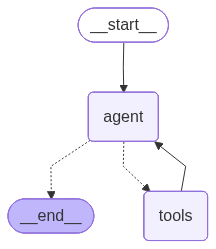

In [11]:
# ── 11. VISUALISE THE GRAPH (ASCII / Mermaid) ────────────────────────────────
# LangGraph can render a Mermaid diagram. If graphviz/Pillow are installed
# the PNG version can also be displayed inline in Jupyter.

try:
    from IPython.display import Image, display

    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print the Mermaid source
    print(app.get_graph().draw_mermaid())

In [12]:
# ── 12. SINGLE-TURN QUERY DEMO ───────────────────────────────────────────────
# Each conversation is identified by a `thread_id` config.
# Using the same thread_id later will recall the full history from MemorySaver.

from langchain_core.messages import HumanMessage


def ask(question: str, thread_id: str = "demo-thread-1", verbose: bool = True) -> str:
    """Send a message to the agent and return its final answer."""
    config = {"configurable": {"thread_id": thread_id}}
    result = app.invoke(
        {"messages": [HumanMessage(content=question)]},
        config=config,
    )
    final_msg = result["messages"][-1]
    answer = final_msg.content

    if verbose:
        # Show what happened step by step
        print(f"Q: {question}")
        print("-" * 60)
        for msg in result["messages"]:
            role = type(msg).__name__
            if hasattr(msg, "tool_calls") and msg.tool_calls:
                calls = [{"name": tc["name"], "args": tc["args"]} for tc in msg.tool_calls]
                print(f"[{role}] → tool_calls: {calls}")
            elif isinstance(msg, ToolMessage):
                preview = str(msg.content)[:150].replace("\n", " ")
                print(f"[ToolMessage:{msg.name}] → {preview}...")
            elif isinstance(msg, HumanMessage):
                pass  # already printed above
            else:
                if msg.content:
                    print(f"[{role}] {msg.content}")
    return answer


# First question on a fresh thread
answer1 = ask(
    "What is this book about??",
    thread_id="thread-001",
)

InternalServerError: Error code: 500 - {'error': {'message': 'Internal Server Error', 'code': 500}}

In [13]:
# ── 13. MULTI-TURN CONVERSATION DEMO ─────────────────────────────────────────
# Because we use the SAME thread_id, the agent remembers previous turns.
# The MemorySaver replays the full message history on every invocation.

print("=" * 60)
print("MULTI-TURN CONVERSATION (thread: thread-002)")
print("=" * 60)

THREAD = "thread-002"

# Turn 1
print("\n── Turn 1 ──")
ask("What is a Transformer and why does it matter for LLMs?", thread_id=THREAD)

# Turn 2 — follow-up referring to Turn 1 context
print("\n── Turn 2 ──")
ask(
    "You mentioned attention. How does that compare to what backpropagation does?", thread_id=THREAD
)

# Turn 3 — structural / page-level question
print("\n── Turn 3 ──")
ask("Which chapter covers deployment and production?", thread_id=THREAD)

# Inspect saved state directly from MemorySaver
snapshot = app.get_state({"configurable": {"thread_id": THREAD}})
n_msgs = len(snapshot.values.get("messages", []))
print(f"\nMessages stored in MemorySaver for thread '{THREAD}': {n_msgs}")

MULTI-TURN CONVERSATION (thread: thread-002)

── Turn 1 ──
Q: What is a Transformer and why does it matter for LLMs?
------------------------------------------------------------
[AIMessage] → tool_calls: [{'name': 'search_document', 'args': {'query': 'what is a Transformer and why does it matter for LLMs'}}]
[ToolMessage:search_document] → [Result 1 | page 109 | type=node_text | score=11.5] Title: farmer. He does not farmer. He does not parents pay have to pay income taxes ? tax on agric...
[AIMessage] The provided document does not contain information about Transformers or their role in Large Language Models (LLMs). The document appears to be a textbook covering topics such as taxation, statistics (frequency distribution tables), and polynomial division.

── Turn 2 ──
Q: You mentioned attention. How does that compare to what backpropagation does?
------------------------------------------------------------
[AIMessage] → tool_calls: [{'name': 'search_document', 'args': {'query': 'what 

In [14]:
# ── 14. STREAMING OUTPUT ─────────────────────────────────────────────────────
# LangGraph supports streaming graph events. Here we stream token-by-token output
# AND graph step events so you can see which node is executing.


config = {"configurable": {"thread_id": "thread-streaming"}}
user_input = {"messages": [HumanMessage(content="Summarise the chapter on evaluation metrics.")]}

print("Streaming graph events:\n")
for event in app.stream(user_input, config=config, stream_mode="values"):
    last_msg = event["messages"][-1]
    role = type(last_msg).__name__
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        print(f"  [{role}] emitting tool_calls → {[tc['name'] for tc in last_msg.tool_calls]}")
    elif isinstance(last_msg, ToolMessage):
        print(f"  [ToolMessage:{last_msg.name}] returned {len(str(last_msg.content))} chars")
    else:
        preview = str(last_msg.content)[:200].replace("\n", " ")
        print(f"  [{role}]: {preview}{'...' if len(str(last_msg.content)) > 200 else ''}")

print("\nStream complete.")

Streaming graph events:

  [HumanMessage]: Summarise the chapter on evaluation metrics.
  [AIMessage] emitting tool_calls → ['search_document']
  [ToolMessage:search_document] returned 3371 chars
  [AIMessage]: The provided document does not contain a specific chapter dedicated to "evaluation metrics."  Page 147 mentions an "Evaluation scheme" in the context of a "Practical Notebook for Standard IX," noting ...

Stream complete.


---
## Bonus: Using the NullVector LLM Gateway inside a LangGraph Node

NullVector ships its own typed LLM gateway (`GatewayService`) that handles structured
output, retries, and audit logging.  You can call it from inside a custom LangGraph node
to generate node summaries or run document repair on-the-fly.

> **Note on LiteLLM:** The gateway internally calls `litellm.responses()`, which
> is LiteLLM's Responses-API endpoint. OpenRouter supports this via a compatibility
> shim, but you may need `litellm >= 1.50` for full support.  If you hit issues, see the
> custom adapter pattern in the cell below.

In [ ]:
# ── 15. NULLVECTOR GATEWAY CONFIGURATION ────────────────────────────────────
# Configure NullVector's own LLM gateway to use OpenRouter via LiteLLM.

from nullvector.llm import GatewayConfig, GatewayService
from nullvector.llm.adapters import LiteLLMAdapter
from nullvector.llm.types import GatewayAuditConfig

nv_gateway_config = GatewayConfig(
    default_model=LITELLM_MODEL,
    timeout_seconds=30.0,
    audit=GatewayAuditConfig(
        persist_root=None,  # set to a directory path to save audit records
        capture_raw_request=False,
        capture_raw_response=False,
    ),
)

nv_gateway = GatewayService(nv_gateway_config, provider_adapter=LiteLLMAdapter())
print("NullVector GatewayService configured.")

# ── Example: call the gateway directly with a structured output model ────────
from nullvector.domain import NonEmptyStr
from nullvector.domain.common import StrataModel
from nullvector.llm.types import GatewayRequest, LLMMessage, LLMRole


class OneLinerSummary(StrataModel):
    """A single-sentence summary of a document section."""

    sentence: NonEmptyStr

def summarise_via_nv_gateway(text: str) -> str:
    """Use NullVector's gateway to summarise a text excerpt."""
    request = GatewayRequest[OneLinerSummary](
        operation_name="one_liner_summary",
        messages=(
            LLMMessage(
                role=LLMRole.SYSTEM,
                content="You are a precise technical summariser. Respond only with the schema.",
            ),
            LLMMessage(
                role=LLMRole.USER,
                content=f"Produce a one-sentence summary of:\n\n{text[:800]}",
            ),
        ),
        response_model=OneLinerSummary,
        temperature=0.0,
    )
    result = nv_gateway.invoke(request)
    return result.output.sentence

# Test: summarise the first page
first_page_units = [
    u for u in corpus.units if u.unit_type.value == "page_text" and u.page_span.start_page == 0
]
if first_page_units:
    page_text = first_page_units[0].text or ""
    try:
        summary = summarise_via_nv_gateway(page_text)
        print(f"One-liner summary of page 1:\n  {summary}")
    except Exception as exc:
        print(f"Gateway call failed (check LiteLLM/OpenRouter compat): {exc}")

In [ ]:
# ── 16. LANGGRAPH NODE USING NULLVECTOR GATEWAY ──────────────────────────────
# We show how to add a dedicated 'summarise_pages' node to a LangGraph graph
# that uses the NullVector gateway to generate structured summaries, then
# injects them back into the conversation as a SystemMessage.

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph


class EnrichedState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    summaries_injected: bool


def summarise_pages_node(state: EnrichedState) -> dict:
    """Pre-compute page summaries with the NullVector gateway and inject them
    into the conversation context before the first LLM call."""
    if state.get("summaries_injected"):
        return {}  # already done — skip

    page_units = [u for u in corpus.units if u.unit_type.value == "page_text" and u.text]
    summaries = []
    for unit in page_units[:3]:  # limit to first 3 pages for demo speed
        page_num = unit.page_span.start_page + 1
        try:
            s = summarise_via_nv_gateway(unit.text)
            summaries.append(f"Page {page_num}: {s}")
        except Exception:
            summaries.append(f"Page {page_num}: (summary unavailable)")

    context_msg = SystemMessage(
        content="Document page summaries (pre-computed):\n" + "\n".join(summaries)
    )
    return {"messages": [context_msg], "summaries_injected": True}


# Assemble an enriched graph with a pre-summarisation step
enriched_graph = StateGraph(EnrichedState)
enriched_graph.add_node("summarise", summarise_pages_node)
enriched_graph.add_node("agent", call_model)
enriched_graph.add_node("tools", execute_tools)
enriched_graph.set_entry_point("summarise")
enriched_graph.add_edge("summarise", "agent")
enriched_graph.add_conditional_edges(
    "agent",
    should_continue,
    {"tools": "tools", END: END},
)
enriched_graph.add_edge("tools", "agent")

enriched_memory = MemorySaver()
enriched_app = enriched_graph.compile(checkpointer=enriched_memory)

print("Enriched graph (with NullVector gateway pre-summarisation) compiled.")

# Run a query through the enriched graph
print("\nRunning query through enriched graph...")
cfg = {"configurable": {"thread_id": "enriched-001"}}
result = enriched_app.invoke(
    {
        "messages": [HumanMessage(content="What does chapter 1 discuss?")],
        "summaries_injected": False,
    },
    config=cfg,
)
print("\nAnswer:", result["messages"][-1].content)

In [ ]:
# ── 17. EXPORT CORPUS TO LANGCHAIN DOCUMENTS ────────────────────────────────
# NullVector includes edge exporters for LangChain and LlamaIndex.
# This lets you slot NullVector's structured corpus into any LangChain RAG pipeline.

import json

from nullvector.domain import NodeCard
from nullvector.export import to_langchain_documents

# Load node cards if tree was built
lc_docs = []
if TREE_MANIFEST_PATH:
    tree_manifest_obj = __import__("json")  # just to load JSON below
    from nullvector.domain import NodeCard

    cards_path = None
    with open(TREE_MANIFEST_PATH) as f:
        tm = json.load(f)
    cards_path = tm.get("node_cards_path")

    if cards_path and Path(cards_path).exists():
        with open(cards_path) as f:
            raw_cards = json.load(f)
        node_cards = tuple(NodeCard.model_validate(c) for c in raw_cards)
        lc_docs = to_langchain_documents(node_cards)
        print(f"Exported {len(lc_docs)} LangChain documents from NullVector node cards.")
        if lc_docs:
            first = lc_docs[0]
            print("\nFirst document preview:")
            print(f"  page_content: {str(first.page_content)[:200]}")
            print(f"  metadata keys: {list(first.metadata.keys())}")
    else:
        print("Node cards not found — skipping LangChain export.")
else:
    print("Tree build was skipped — no node cards to export.")
    print("(Set RUN_TREE_BUILD = True in cell 5 to enable this.)")

In [ ]:
# ── 18. INSPECT IN-MEMORY STATE ──────────────────────────────────────────────
# MemorySaver stores all thread states in a dict-like structure in RAM.
# Here we show how to list threads, replay history, and manually inject state.

# List all threads currently in MemorySaver
# (access the underlying store — implementation detail but useful for debugging)
print("Threads in MemorySaver:")
for thread_id in ["thread-001", "thread-002", "thread-streaming"]:
    cfg = {"configurable": {"thread_id": thread_id}}
    try:
        snap = app.get_state(cfg)
        n = len(snap.values.get("messages", []))
        print(f"  {thread_id}: {n} messages")
    except Exception:
        print(f"  {thread_id}: (no state)")

# Replay thread-001 history
print("\nFull message history for thread-001:")
snap = app.get_state({"configurable": {"thread_id": "thread-001"}})
for msg in snap.values.get("messages", []):
    role = type(msg).__name__.replace("Message", "")
    preview = str(msg.content)[:100].replace("\n", " ") if msg.content else "(tool_calls)"
    print(f"  [{role:12s}] {preview}")

---
## Multimodal Section — Visual Region Enrichment

NullVector's `enrich_visual_region` function sends cropped image regions to a vision LLM
and attaches the structured insight back to the corpus unit. The workflow is:

```
CanonicalDocumentLedger
  └─ VisualArtifact / UnresolvedRegion  (block_type = visual_artifact / unresolved_region)
       └─► asset_path (PNG crop written by acquisition)  ──► LiteLLM SDK Adapter
             └─► VisualInsightResponse (structured)  ──► VisualEnrichmentAttachment
                   └─► augment_corpus_with_attachments  ──► enriched RetrievalCorpus
                         └─► describe_image LangGraph tool
```

**Model used:** `google/gemini-2.0-flash` via OpenRouter (supports vision).

In [ ]:
# ── MM-1. INSPECT VISUAL ARTIFACTS FROM ACQUISITION ─────────────────────────
# After acquisition, every embedded image becomes a VisualArtifact and
# every image-only / dense-vector page becomes an UnresolvedRegion.
# Both get a PNG crop written to  assets/pages/<idx>/<id>.png  by
# materialize_visual_assets() inside AcquisitionService.

import json
from pathlib import Path

from nullvector.domain import CanonicalDocumentLedger

ledger_path = Path(acq_manifest.artifact_root) / "ledger" / "canonical-document-ledger.json"
with open(ledger_path) as f:
    ledger = CanonicalDocumentLedger.model_validate(json.load(f))

visual_blocks = []
unresolved_blocks = []
for page in ledger.pages:
    for block in page.blocks:
        if block.block_type == "visual_artifact":
            visual_blocks.append((page.page_index, block))
        elif block.block_type == "unresolved_region":
            unresolved_blocks.append((page.page_index, block))

print(f"VisualArtifact blocks    : {len(visual_blocks)}")
print(f"UnresolvedRegion blocks  : {len(unresolved_blocks)}")

# Show the first few with their asset paths
all_visual = visual_blocks + unresolved_blocks
print("\nFirst enrichable blocks:")
for pg_idx, blk in all_visual[:5]:
    asset = getattr(blk, "asset_path", None) or getattr(blk, "page_render_path", None)
    exists = Path(asset).exists() if asset else False
    block_id = getattr(blk, "visual_id", None) or getattr(blk, "region_id", None)
    print(f"  page {pg_idx + 1}  {blk.block_type:<20} id={block_id}")
    print(f"           asset: {asset}  (exists={exists})")

if not all_visual:
    print("\nNo visual blocks found. The PDF may be pure text or images may be")
    print("very small vectors below the detection threshold.")
    print("Multimodal enrichment cells will still run but produce no attachments.")

In [ ]:
# ── MM-2. CONFIGURE THE VISION GATEWAY ───────────────────────────────────
# GatewayService wraps litellm.completion() with image_url content.
#
# For OpenRouter we pass:
#   model  = "openrouter/google/gemini-2.0-flash"
#   The gateway handles routing via default_model.

from nullvector.llm import (
    GatewayConfig,
    GatewayError,
    GatewayService,
    enrich_visual_region,
)
from nullvector.llm.adapters import LiteLLMAdapter

mm_gateway_cfg = GatewayConfig(
    default_model=VISION_LITELLM_MODEL,
    timeout_seconds=45.0,
)

vision_gateway = GatewayService(mm_gateway_cfg, provider_adapter=LiteLLMAdapter())

print("GatewayService ready (vision).")
print(f"  Vision model : {VISION_LITELLM_MODEL}")
print("  Provider     : litellm -> OpenRouter")

In [ ]:
# ── MM-3. ENRICH VISUAL REGIONS ──────────────────────────────────────────────
# We iterate over the visual/unresolved blocks and call enrich_visual_region()
# for each one that has a materialized asset path.
#
# Results are VisualEnrichmentAttachment objects containing:
#   .insight.summary   — natural-language description of the image
#   .insight.labels    — detected category labels
#   .insight.attributes — key-value facts extracted from the image
#   .confidence        — 0-1 confidence from the structured response
#
# We cap at MAX_ENRICHMENTS to keep runtime / cost reasonable.

import hashlib

from nullvector.domain import VisualEnrichmentRequest, VisualRegionReference

MAX_ENRICHMENTS = 5  # increase once you're happy with the setup

enrichment_attachments = []


def _make_enrichment_request(page_index, blk):
    """Build a VisualEnrichmentRequest from a VisualArtifact or UnresolvedRegion."""
    is_visual = blk.block_type == "visual_artifact"
    region_id = blk.visual_id if is_visual else blk.region_id
    asset_path = blk.asset_path or blk.page_render_path

    region = VisualRegionReference(
        document_id=ledger.document_id,
        page_index=page_index,
        region_id=region_id,
        bbox=blk.bbox,
        asset_path=blk.asset_path,
        page_render_path=blk.page_render_path,
        render_dpi=getattr(blk, "render_dpi", None),
    )
    request_id = hashlib.sha256(f"{ledger.document_id}:{region_id}".encode()).hexdigest()[:24]
    return VisualEnrichmentRequest(
        request_id=request_id,
        region=region,
        prompt=(
            "Describe this image concisely. Identify: "
            "(1) what type of visual it is (chart, diagram, photo, table, etc.), "
            "(2) key information or data shown, "
            "(3) any visible text or labels. "
            "Be specific and grounded in what is visually present."
        ),
    )


enriched_count = 0
skipped_no_asset = 0

for page_index, blk in all_visual:
    if enriched_count >= MAX_ENRICHMENTS:
        break
    asset = blk.asset_path or blk.page_render_path
    if not asset or not Path(asset).exists():
        skipped_no_asset += 1
        continue

    req = _make_enrichment_request(page_index, blk)
    try:
        attachment = enrich_visual_region(vision_gateway, req)
        enrichment_attachments.append(attachment)
        enriched_count += 1
        region_id = blk.visual_id if blk.block_type == "visual_artifact" else blk.region_id
        print(f"page {page_index + 1} [{region_id[:20]}]")
        print(f"  summary    : {attachment.insight.summary[:120]}")
        print(f"  labels     : {list(attachment.insight.labels)[:5]}")
        print(f"  confidence : {attachment.confidence}")
        print()
    except GatewayError as exc:
        print(
            f"page {page_index + 1} — gateway error: {exc.failure.category.value}: {exc.failure.message[:80]}"
        )
    except Exception as exc:
        print(f"page {page_index + 1} — unexpected error: {exc}")

print(f"Enriched {enriched_count} visual regions  |  skipped (no asset): {skipped_no_asset}")
print(f"Total attachments collected: {len(enrichment_attachments)}")

In [ ]:
# ── MM-4. AUGMENT THE CORPUS WITH ATTACHMENTS ────────────────────────────────
# augment_corpus_with_attachments() folds each VisualEnrichmentAttachment back
# into its matching corpus unit:
#   unit.text      ← attachment.insight.summary  (now searchable by the ranker)
#   unit.keywords  ← attachment.insight.labels
#   unit.interpretive = True  (signals it's LLM-derived, not native text)
#
# The enriched_corpus is a NEW immutable object (NullVector uses frozen pydantic).
# We rebuild the index and service on top of it.

from nullvector.retrieval import (
    InMemoryRetrievalIndex,
    RetrievalService,
    augment_corpus_with_attachments,
)

if enrichment_attachments:
    enriched_corpus = augment_corpus_with_attachments(
        corpus=corpus,
        attachments=tuple(enrichment_attachments),
    )
else:
    enriched_corpus = corpus  # no-op if nothing was enriched

enriched_index = InMemoryRetrievalIndex(enriched_corpus)
enriched_service = RetrievalService(planner, ranker)

# How many visual units now have text?
visual_with_text = [
    u
    for u in enriched_corpus.units
    if u.unit_type.value in ("visual", "unresolved_visual") and u.text
]
print(f"Visual units with enriched text: {len(visual_with_text)}")
for u in visual_with_text[:3]:
    print(f"  [{u.unit_id[:30]}] page {u.page_span.start_page + 1}: {(u.text or '')[:100]}")

In [ ]:
# ── MM-5. ADD describe_image TOOL AND REBUILD THE AGENT ─────────────────────
# The new tool has two modes:
#   1. If the corpus already has cached enrichment text for a visual unit -> return it
#      instantly (no extra LLM call).
#   2. If not yet enriched -> call enrich_visual_region() live and return the result.
#
# We also swap the agent's corpus to the enriched_corpus so search_document
# automatically picks up the visual text as well.

from typing import Annotated, TypedDict

from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages


# ── Override search_document to use the enriched corpus ─────────────────────
@tool
def search_document_mm(query: str, limit: int = 5) -> str:
    """Search the document (including enriched image descriptions) for content
    relevant to the query. Returns ranked excerpts with page numbers.
    Args:
        query: Natural language search query.
        limit: Max results (default 5).
    """
    hits = enriched_service.search(
        corpus=enriched_corpus, query=query, limit=max(1, min(int(limit), 10))
    )
    if not hits:
        return "No relevant content found."
    parts = []
    for i, hit in enumerate(hits, 1):
        page_label = hit.unit.page_span.start_page + 1
        title = hit.unit.title or "(untitled)"
        text = (hit.unit.text or "").strip()
        excerpt = text[:600] + ("..." if len(text) > 600 else "")
        unit_type = hit.unit.unit_type.value
        interpretive = " [llm-enriched]" if hit.unit.interpretive else ""
        parts.append(
            f"[Result {i} | page {page_label} | type={unit_type}{interpretive} | score={hit.score:.1f}]\n"
            f"Title: {title}\n{excerpt}"
        )
    return "\n\n".join(parts)


@tool
def describe_image(page_number: int, image_index: int = 0) -> str:
    """Describe a specific image on a given page of the document.
    Returns a detailed description of the image content.
    If the image has already been enriched, returns the cached description.
    If not, calls the vision model live.
    Args:
        page_number: 1-indexed page number containing the image.
        image_index: 0-indexed position among images on that page (default 0 = first).
    """
    page_index = max(0, int(page_number) - 1)
    image_index = max(0, int(image_index))

    # Find visual units on this page
    visual_units = [
        u
        for u in enriched_corpus.units
        if u.unit_type.value in ("visual", "unresolved_visual")
        and u.page_span.start_page == page_index
    ]

    if not visual_units:
        return f"No visual regions found on page {page_number}."
    if image_index >= len(visual_units):
        return (
            f"Page {page_number} has {len(visual_units)} visual region(s); "
            f"index {image_index} is out of range."
        )

    unit = visual_units[image_index]

    # Return cached description if already enriched
    if unit.text and unit.interpretive:
        labels = ", ".join(unit.keywords[:5]) if unit.keywords else "none"
        return (
            f"[Cached enrichment | page {page_number} | {unit.unit_type.value}]\n"
            f"Description: {unit.text}\n"
            f"Labels: {labels}"
        )

    # Otherwise enrich live
    if unit.visual_region is None:
        return f"No asset path available for visual unit on page {page_number}."

    asset = unit.asset_path or unit.page_render_path
    if not asset or not Path(asset).exists():
        return f"Image asset not found on disk for page {page_number}, index {image_index}."

    try:
        req_id = hashlib.sha256(f"{unit.unit_id}:on-demand".encode()).hexdigest()[:24]
        req = VisualEnrichmentRequest(
            request_id=req_id,
            region=unit.visual_region,
            prompt=(
                "Describe this image thoroughly. Include: what type of visual it is, "
                "the main content or data displayed, visible text or axis labels, "
                "and any key takeaways. Be specific."
            ),
        )
        attachment = enrich_visual_region(vision_gateway, req)
        labels = ", ".join(attachment.insight.labels[:5]) if attachment.insight.labels else "none"
        return (
            f"[Live enrichment | page {page_number} | {unit.unit_type.value}]\n"
            f"Description: {attachment.insight.summary}\n"
            f"Labels: {labels}\n"
            f"Confidence: {attachment.confidence}"
        )
    except GatewayError as exc:
        return f"Vision model error: {exc.failure.category.value} — {exc.failure.message}"
    except Exception as exc:
        return f"Unexpected error during image description: {exc}"


@tool
def get_page_text_mm(page_number: int) -> str:
    """Retrieve the complete raw text of a specific page (1-indexed)."""
    page_index = max(0, int(page_number) - 1)
    pages_by_index = {
        u.page_span.start_page: u.text
        for u in enriched_corpus.units
        if u.unit_type.value == "page_text" and u.page_span.start_page == u.page_span.end_page
    }
    text = pages_by_index.get(page_index)
    if text is None:
        return f"Page {page_number} not found. Document has {len(pages_by_index)} pages."
    return f"[Page {page_number}]\n{text.strip()}"


# ── Build the multimodal-aware agent ────────────────────────────────────────
MM_TOOLS = [search_document_mm, describe_image, get_page_text_mm]
MM_TOOL_MAP = {t.name: t for t in MM_TOOLS}

from langchain_openai import ChatOpenAI

# Use the vision model as the backbone — it handles both text and image requests
mm_llm = ChatOpenAI(
    base_url=OPENROUTER_BASE_URL,
    api_key=OPENROUTER_API_KEY,
    model=VISION_LANGCHAIN_MODEL,
    temperature=0.0,
)
mm_llm_with_tools = mm_llm.bind_tools(MM_TOOLS)

MM_SYSTEM = (
    "You are a document assistant with vision capabilities. "
    "You can search document text AND describe images found in the document. "
    "Use describe_image when the user asks about figures, charts, photos, or visual content. "
    "Use search_document_mm for text-based questions. "
    "Always cite page numbers in your answers."
)


def mm_call_model(state):
    msgs = state["messages"]
    if not any(isinstance(m, SystemMessage) for m in msgs):
        msgs = [SystemMessage(content=MM_SYSTEM)] + list(msgs)
    return {"messages": [mm_llm_with_tools.invoke(msgs)]}


def mm_execute_tools(state):
    last = state["messages"][-1]
    tool_messages = []
    for tc in last.tool_calls:
        fn = MM_TOOL_MAP.get(tc["name"])
        try:
            result = fn.invoke(tc["args"]) if fn else f"Unknown tool: {tc['name']}"
        except Exception as exc:
            result = f"Tool error: {exc}"
        tool_messages.append(
            ToolMessage(content=str(result), tool_call_id=tc["id"], name=tc["name"])
        )
    return {"messages": tool_messages}


def mm_should_continue(state):
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and getattr(last, "tool_calls", None):
        return "tools"
    return END


class MMState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


mm_graph = StateGraph(MMState)
mm_graph.add_node("agent", mm_call_model)
mm_graph.add_node("tools", mm_execute_tools)
mm_graph.set_entry_point("agent")
mm_graph.add_conditional_edges("agent", mm_should_continue, {"tools": "tools", END: END})
mm_graph.add_edge("tools", "agent")

mm_memory = MemorySaver()
mm_app = mm_graph.compile(checkpointer=mm_memory)

print("Multimodal LangGraph agent compiled.")
print(f"Tools: {[t.name for t in MM_TOOLS]}")
print(f"Model: {VISION_LANGCHAIN_MODEL}")

In [ ]:
# ── MM-6. MULTIMODAL AGENT DEMO ───────────────────────────────────────────────
# Run queries that mix text retrieval and image description.


def ask_mm(question: str, thread_id: str = "mm-thread-1", verbose: bool = True) -> str:
    config = {"configurable": {"thread_id": thread_id}}
    result = mm_app.invoke(
        {"messages": [HumanMessage(content=question)]},
        config=config,
    )
    final = result["messages"][-1].content
    if verbose:
        print(f"Q: {question}")
        print("-" * 60)
        for msg in result["messages"]:
            role = type(msg).__name__
            if isinstance(msg, HumanMessage):
                continue
            elif hasattr(msg, "tool_calls") and msg.tool_calls:
                for tc in msg.tool_calls:
                    print(f"[{role}] → tool: {tc['name']}({tc['args']})")
            elif isinstance(msg, ToolMessage):
                preview = str(msg.content)[:160].replace("\n", " ")
                print(f"[Tool:{msg.name}] → {preview}...")
            else:
                print(f"[Answer] {final}")
    return final


print("=" * 60)
print("TEXT QUERY")
print("=" * 60)
ask_mm("What is the main topic of this document?", thread_id="mm-001")

print()
print("=" * 60)
print("IMAGE QUERY — describe first image found")
print("=" * 60)
# Find the first page that has a visual block
_first_visual_page = (all_visual[0][0] + 1) if all_visual else 1
ask_mm(
    f"Describe the image or figure on page {_first_visual_page} of the document.",
    thread_id="mm-001",
)

print()
print("=" * 60)
print("FOLLOW-UP (multi-turn — agent remembers context)")
print("=" * 60)
ask_mm(
    "Based on what you saw in that image, does it relate to the text content nearby?",
    thread_id="mm-001",
)

In [ ]:
# ── MM-7. DISPLAY ENRICHED IMAGE INLINE (Jupyter) ────────────────────────────
# If running in Jupyter, display the PNG crop that was sent to the vision model.

try:
    from IPython.display import Image, Markdown, display

    if enrichment_attachments:
        # Show the first enriched attachment
        att = enrichment_attachments[0]
        # Find the matching corpus unit to get asset_path
        matching_unit = next(
            (
                u
                for u in enriched_corpus.units
                if u.unit_type.value in ("visual", "unresolved_visual")
                and u.visual_region is not None
                and u.visual_region.region_id == att.region_id
            ),
            None,
        )
        if matching_unit and matching_unit.asset_path and Path(matching_unit.asset_path).exists():
            display(
                Markdown(
                    f"**Region:** `{att.region_id}` | **Page:** {matching_unit.page_span.start_page + 1}"
                )
            )
            display(Image(filename=matching_unit.asset_path, width=480))
            display(Markdown(f"**Vision model summary:** {att.insight.summary}"))
            display(Markdown(f"**Labels:** {', '.join(att.insight.labels)}"))
        else:
            print("Asset path not available for inline display.")
    else:
        print("No enriched attachments to display.")
        print("(Run the enrichment cell first, or increase MAX_ENRICHMENTS.)")
except ImportError:
    print("IPython not available — run in Jupyter to display images inline.")

In [ ]:
# ── 19. CLEANUP ──────────────────────────────────────────────────────────────
# Remove all NullVector artifacts from the temp directory.
# Skip this cell if you want to inspect the on-disk artefacts.

import shutil

shutil.rmtree(ARTIFACT_DIR, ignore_errors=True)
print(f"Cleaned up: {ARTIFACT_DIR}")

---
## What to try next

| Goal | How |
|------|-----|
| **Use your own PDF** | Change `PDF_PATH` in cell 4 to your file path |
| **Generate node summaries** | Set `summarize=True` in `TreeBuildRequest` and pass `gateway=nv_gateway` |
| **Visual enrichment** | Use `enrich_visual_region` from `nullvector.llm` with a `GatewayService` |
| **Persist across sessions** | Swap `MemorySaver` for `SqliteSaver` or `PostgresSaver` from `langgraph-checkpoint-*` |
| **Add more tools** | Wrap `RetrievalQAService` or `to_langchain_documents` as LangGraph tools |
| **Custom planner** | Subclass `QueryPlanner` to add domain-specific filters |
| **Export to LlamaIndex** | Use `nullvector.export.to_llamaindex_nodes` in place of `to_langchain_documents` |
| **Stream tokens** | Replace `app.invoke` with `app.astream_events` (async) for real-time output |

### Key NullVector classes reference

```python
from nullvector.ingest    import acquire_document, AcquisitionService
from nullvector.tree      import build_tree, TreeBuildRequest
from nullvector.retrieval import RetrievalCorpusBuilder, InMemoryRetrievalIndex
from nullvector.retrieval import RetrievalService, QueryPlanner, RetrievalRanker
from nullvector.retrieval import RetrievalQAService
from nullvector.llm       import GatewayService, GatewayConfig, enrich_visual_region
from nullvector.export    import to_langchain_documents, to_llamaindex_nodes
from nullvector.observability import EventBus, JsonLoggerSubscriber
```